# Plot color-color diagrams

and overplot ice models. The ice models should track the CCDs.

In [18]:
dmag_mine.add_index('column')
list(dmag_mine.loc[[0,1,2,3,4,5,18,24,25,26,27,28]].loc['column', 1000000000000000]['composition'])

['H2O:CO (0.5:1)',
 'H2O:CO (1:1)',
 'H2O:CO (3:1)',
 'H2O:CO (5:1)',
 'H2O:CO (7:1)',
 'H2O:CO (10:1)',
 'H2O:CO:CO2 (1:1:10)',
 'H2O:CO:CO2:CH3OH:CH3CH2OH (1:1:0.1:1:0.1)',
 'H2O:CO:CO2:CH3OH:CH3CH2OH (1:1:0.1:0.1:0.1)',
 'H2O:CO:CO2:CH3OH:CH3CH2OH (0.1:1:0.1:1:0.1)',
 'H2O:CO:CO2:CH3OH:CH3CH2OH (0.01:1:0.1:0.1:1)',
 'H2O:CO:CO2:CH3OH:CH3CH2OH (0.01:0.1:0.1:0.1:1)']

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

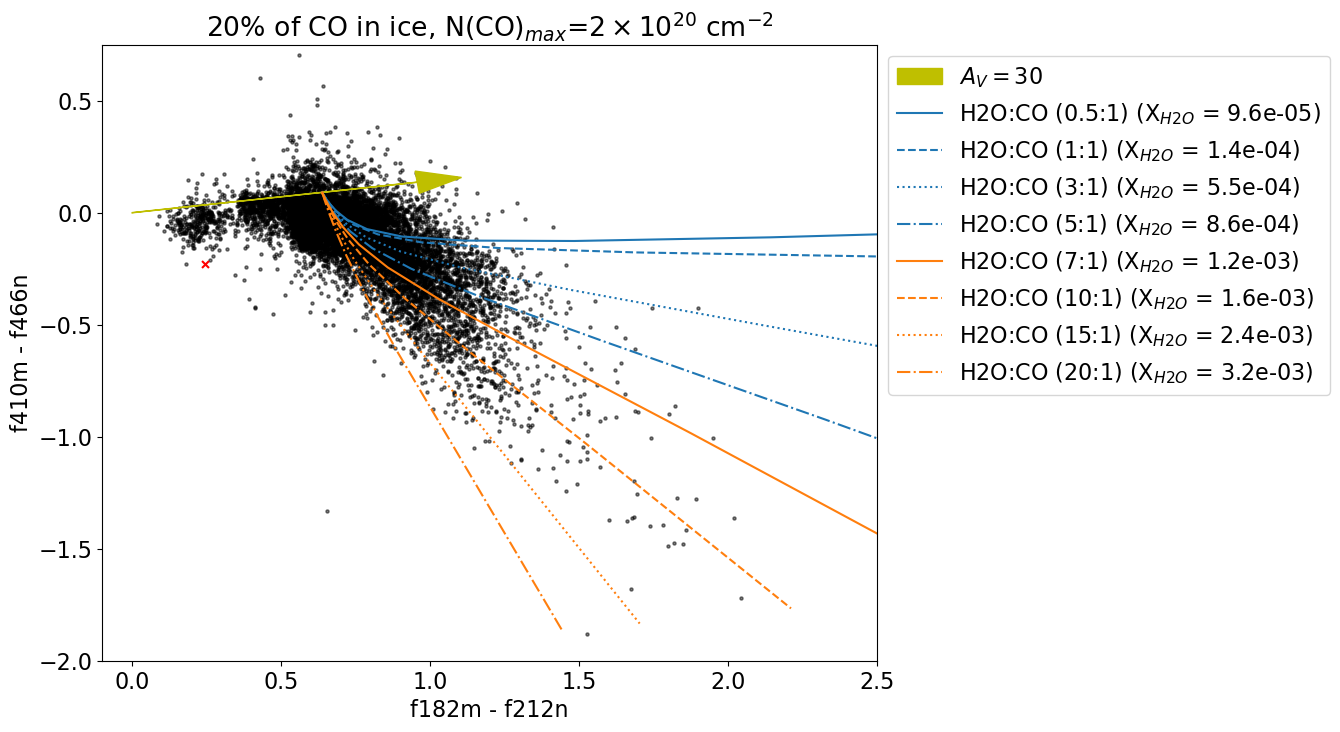

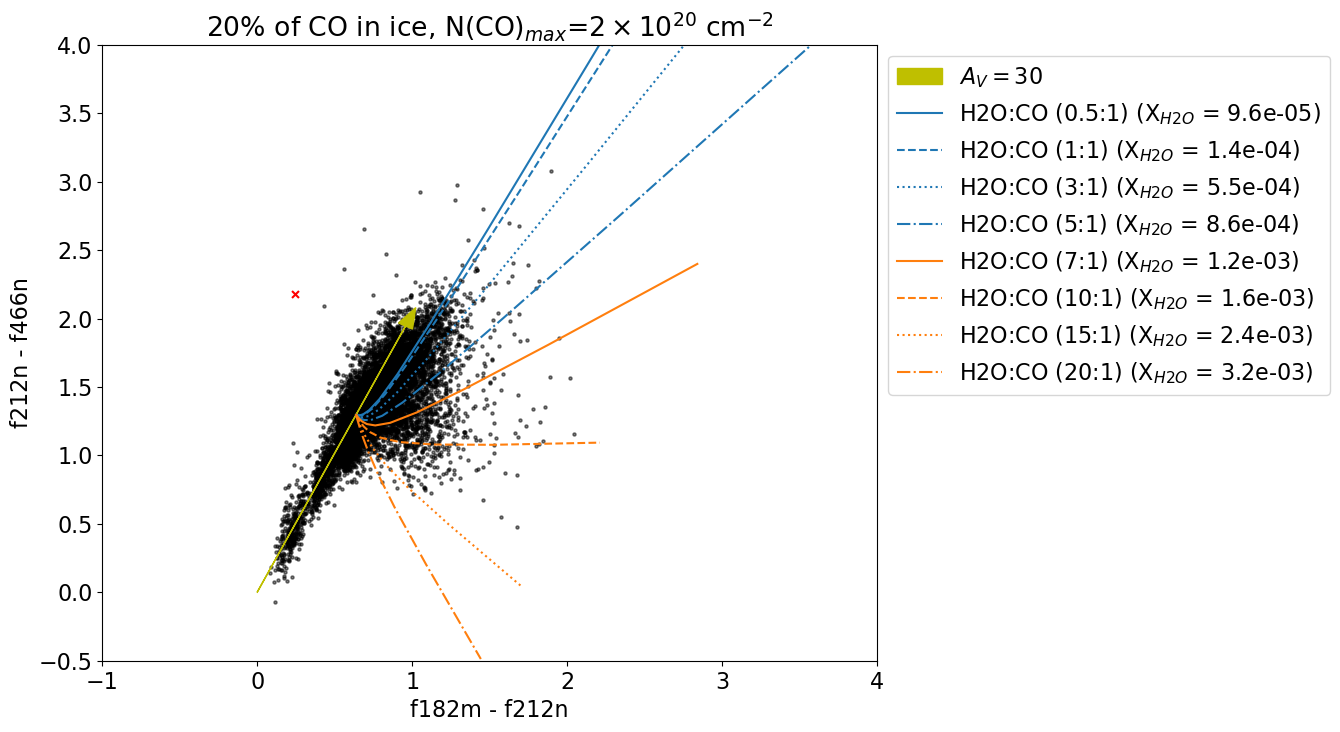

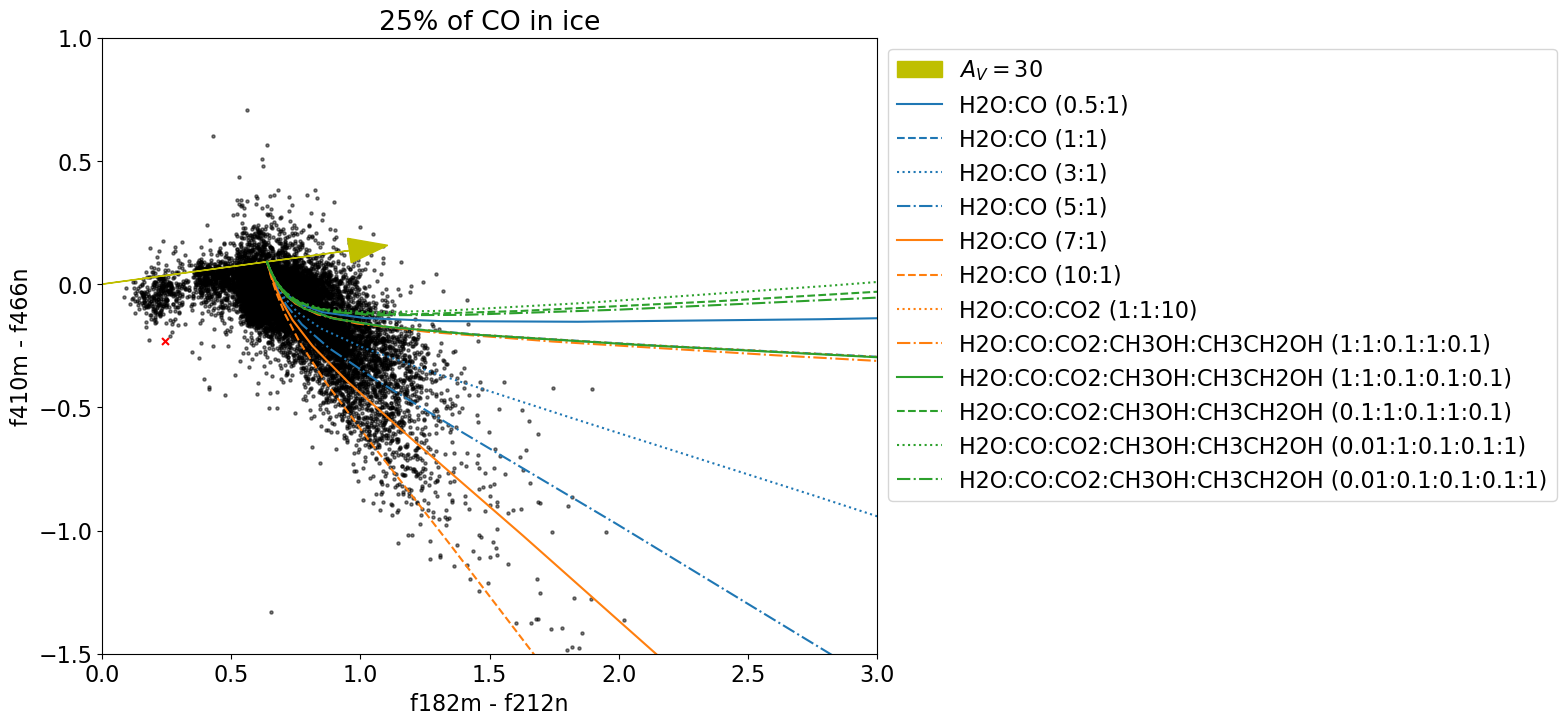

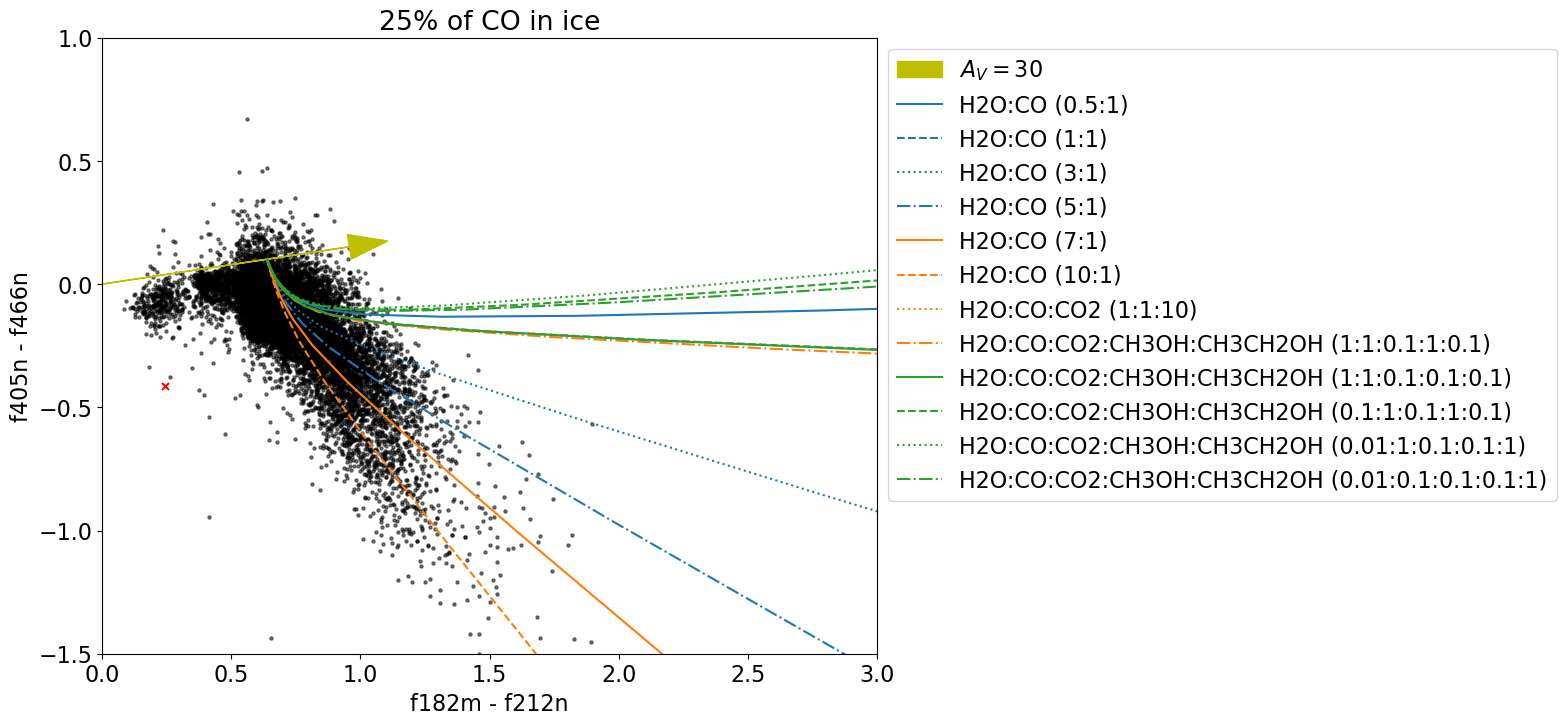

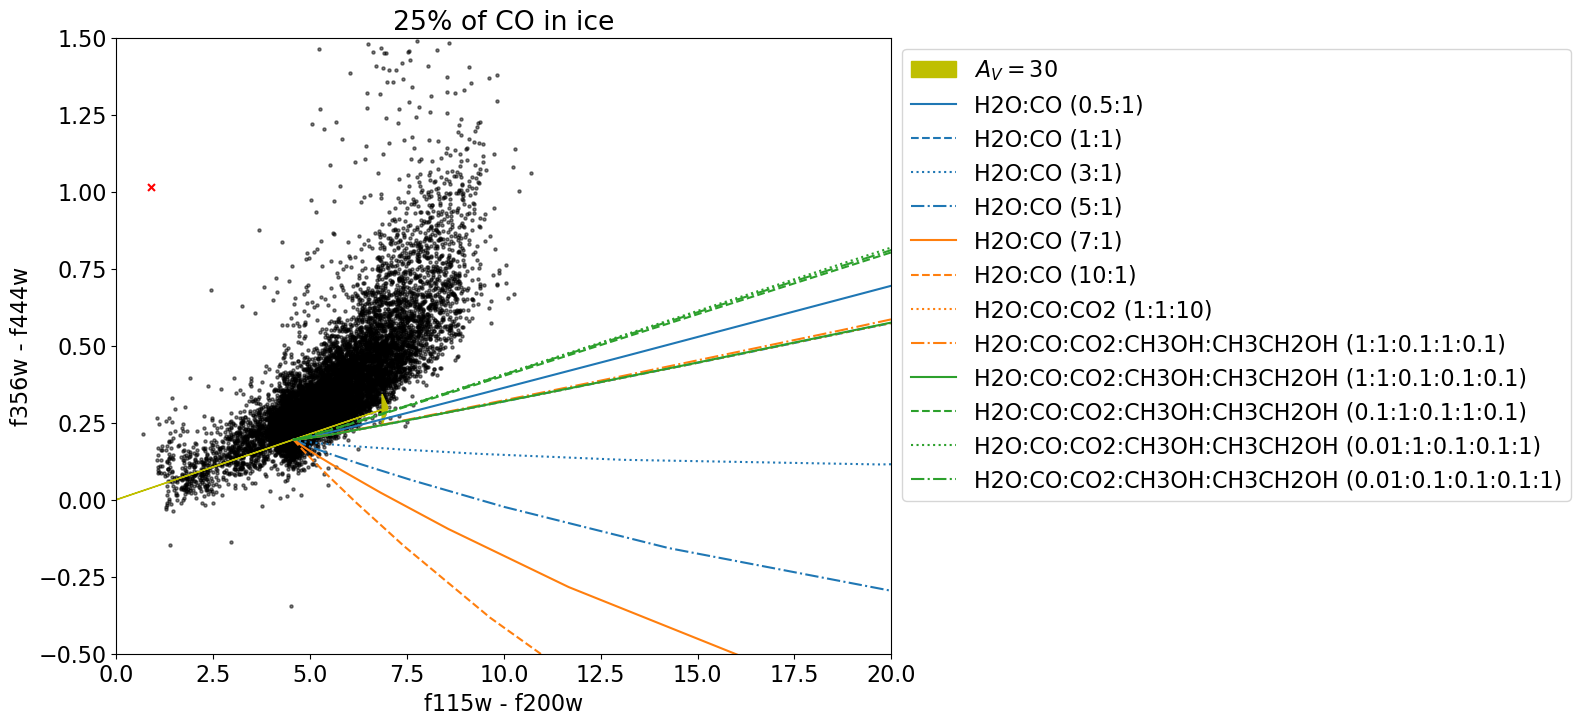

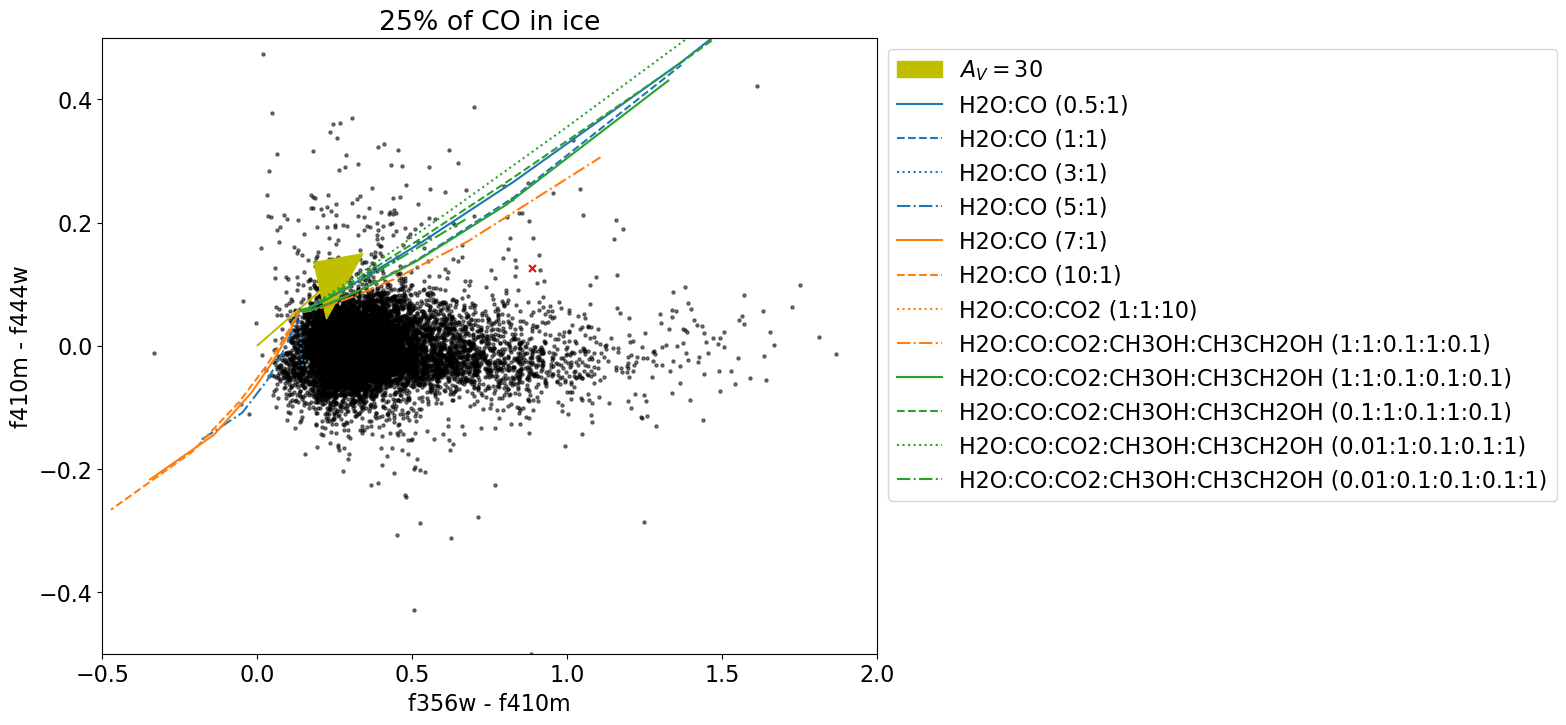

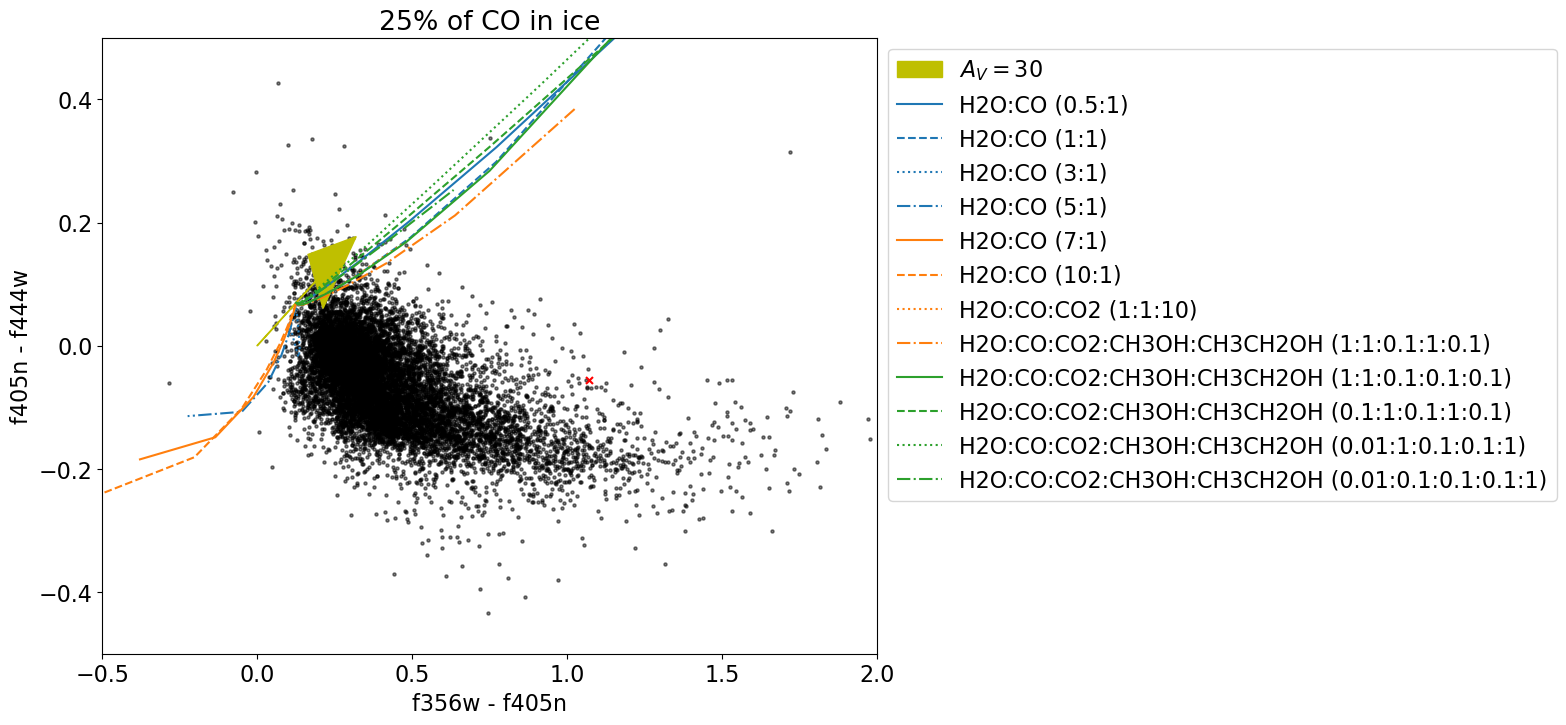

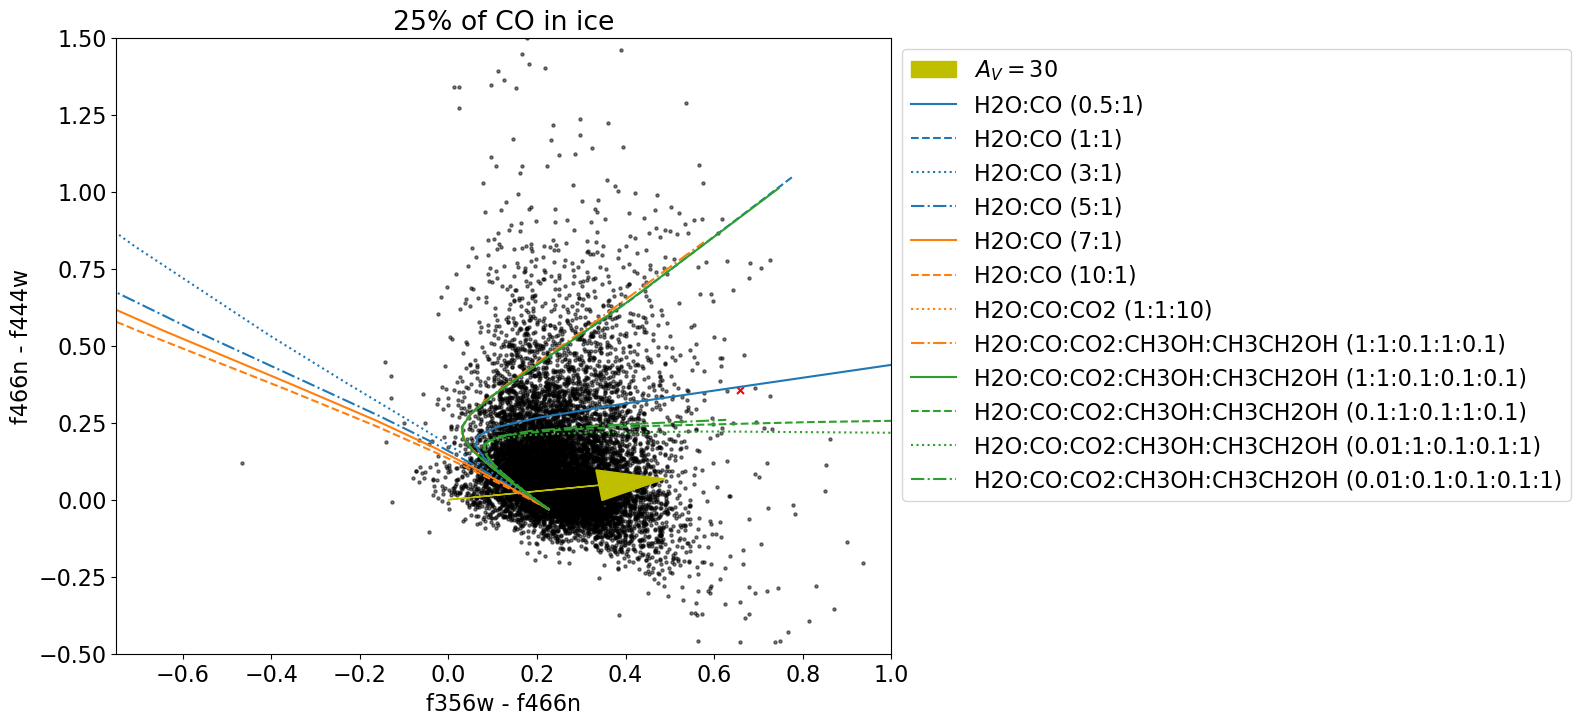

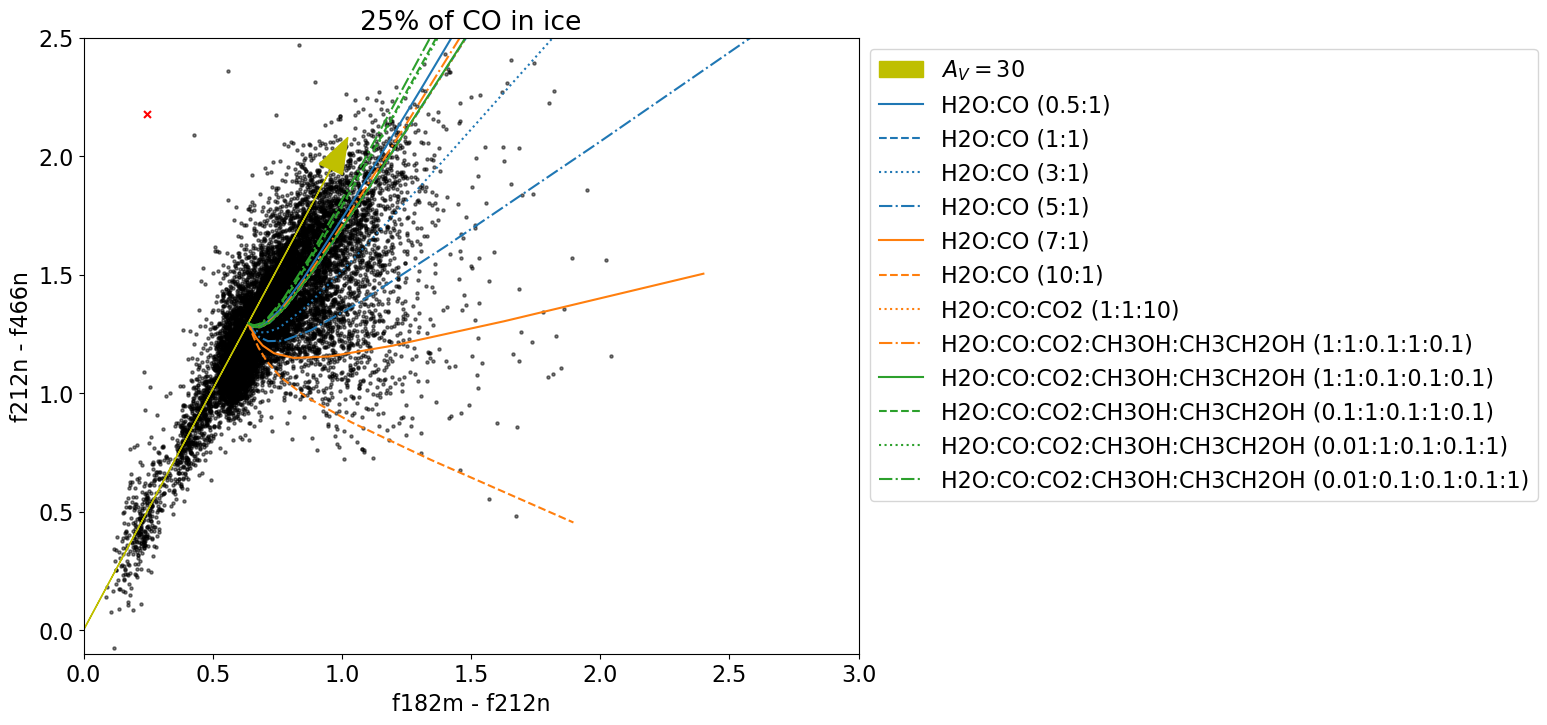

In [25]:
basepath = '/orange/adamginsburg/jwst/brick'
%run -i $basepath/analysis/make_ccd_with_icemodels.py

# Debug/diagnostics: need to exclude some  bad data, was hunting them down (turns out to be bright F182M)

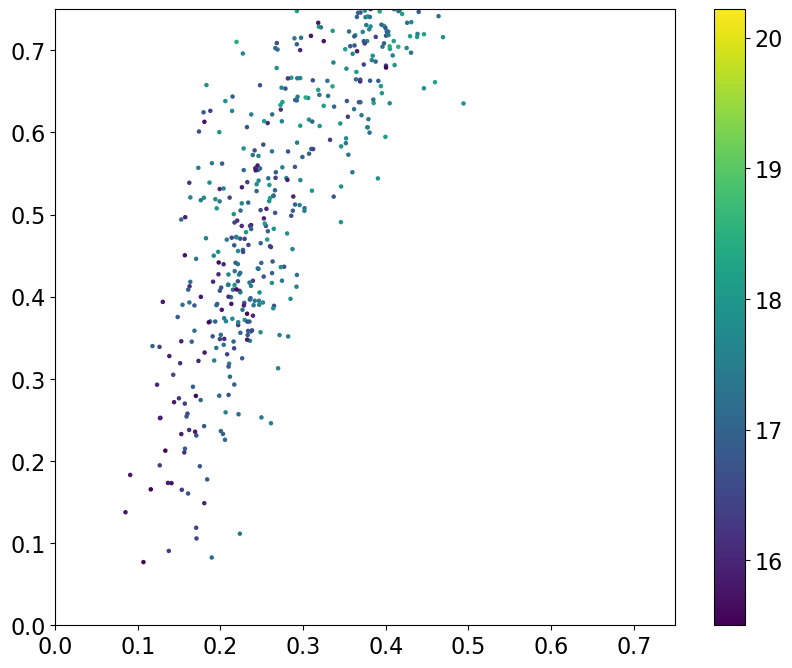

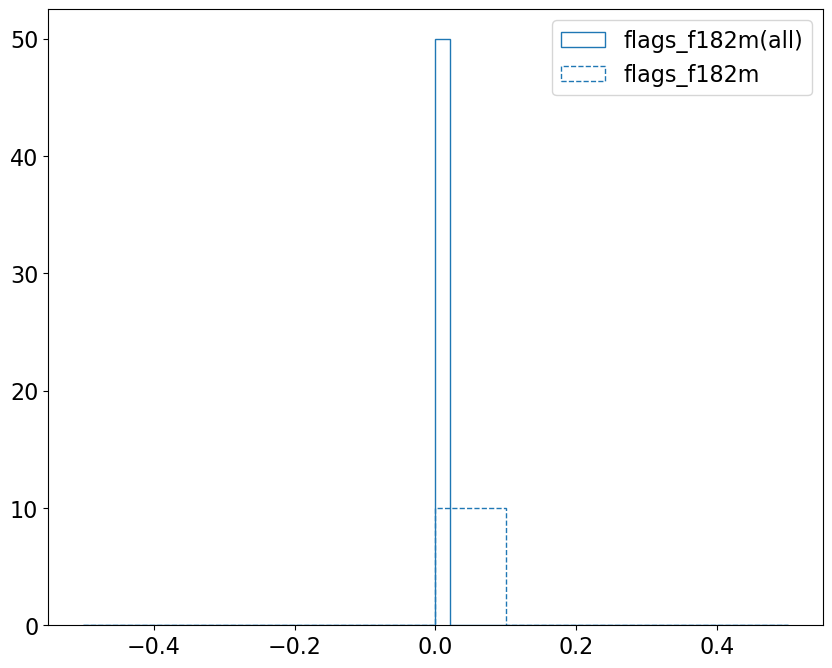

In [21]:
# diagnostics: bad points not being excluded
f182mf212n = basetable['mag_ab_f182m'] - basetable['mag_ab_f212n']
f212nf466n = basetable['mag_ab_f212n'] - basetable['mag_ab_f466n']
mask = (f182mf212n > (f212nf466n+0.25)/2) & (f212nf466n < 0.7)
#pl.scatter(f182mf212n, f212nf466n, s=1)
pl.scatter(f182mf212n[ok], f212nf466n[ok], s=5, c=np.array(basetable['mag_ab_f182m'][ok]))
#pl.scatter(f182mf212n[ok & mask], f212nf466n[ok & mask], s=15, edgecolor='r', facecolor='none')
pl.axis((0,0.75,0,0.75));
pl.colorbar();

pl.figure()
#for par in ('flux_err_prop_f182m', 'flux_err_f182m',)
for par in ('flags_f182m',):#'qfit_f212n', 'qfit_f410m', 'qfit_f466n'):
    pl.hist(basetable[ok][par], histtype='step', label=f'{par}(all)', density=True, bins=50)
    pl.hist(basetable[ok & mask][par], label=par, histtype='step', density=True);
    pl.legend(loc='best')
#[cn for cn in basetable.colnames if '182' in cn]

## Investigate parameters: 50% CO, just H2O:CO ratio

  0%|          | 0/8 [00:00<?, ?it/s]

Text(0.5, 1.0, '50% of CO in ice')

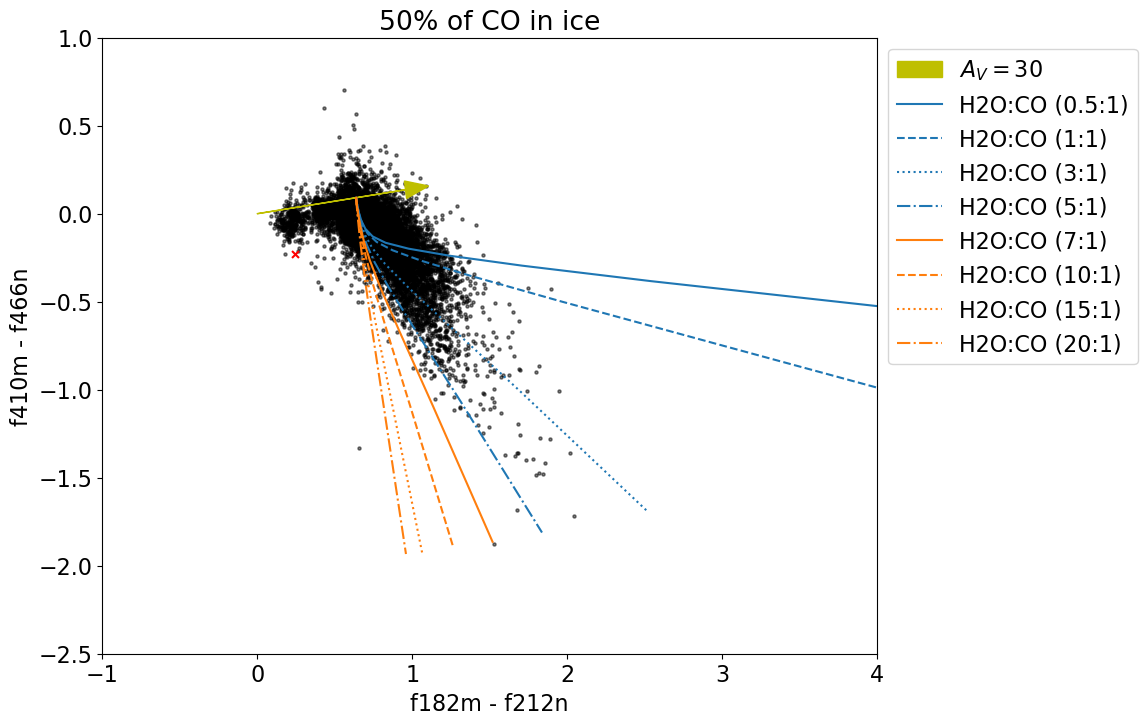

In [24]:
color1= ['F182M', 'F212N']
color2= ['F410M', 'F466N']
a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_with_icemodels(color1, color2, 
                                                                                      molids=None,
  molcomps=['H2O:CO (0.5:1)', 'H2O:CO (1:1)', 'H2O:CO (3:1)', 'H2O:CO (5:1)', 'H2O:CO (7:1)', 'H2O:CO (10:1)', 'H2O:CO (15:1)', 'H2O:CO (20:1)',],
  dmag_tbl=dmag_all.loc['database', 'mymix'],
                                                                                      pure_ice_no_dust=False,
                                                                                  #abundance=3e-4,
                                                                                  #nh2_to_av=1e22,
                                                                                  abundance=0.5*carbon_abundance,
                                                                                  max_column=2e20)
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0))
pl.title("50% of CO in ice")

In [103]:
1/(CT06_MWGC.x_range*u.um**-1)

<Quantity [27.  ,  1.24] um>

In [104]:
carbon_abundance

0.0005011872336272714

## Wide bands 1182

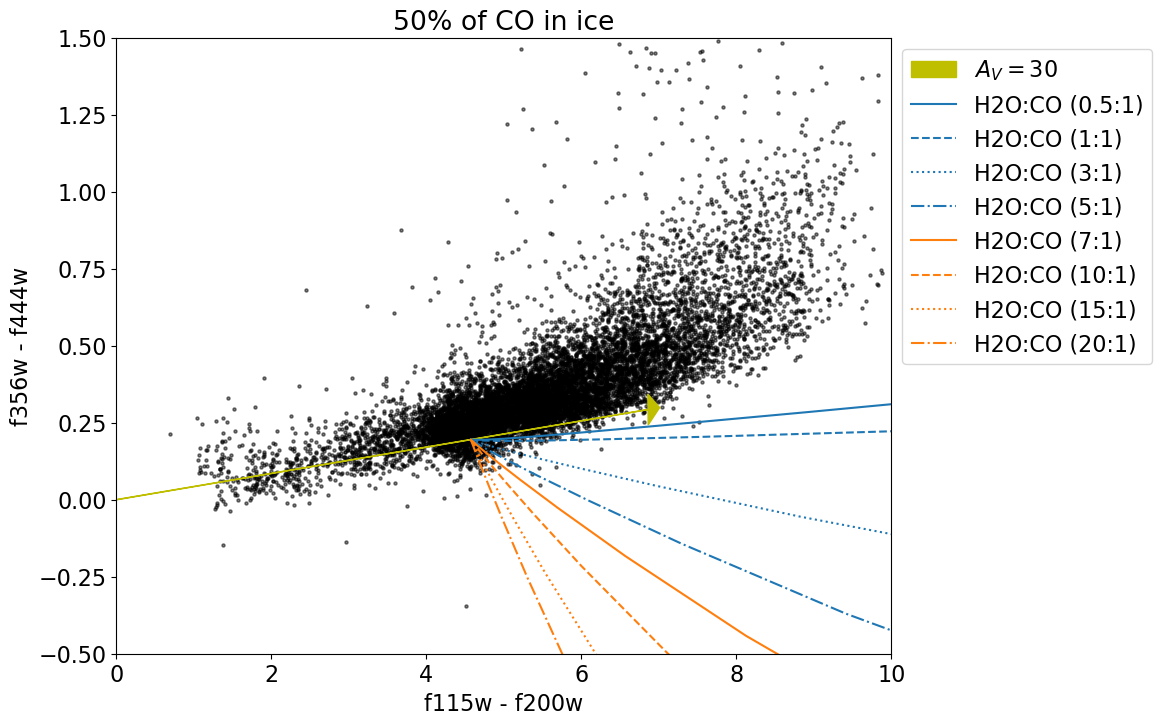

In [105]:
color1= ['F115W', 'F200W']
color2= ['F356W', 'F444W']
a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_with_icemodels(color1, color2, molids=[0,1,2,3,4,5,6,7],#4,5,6,7,8,9,10,11,12,13,14],
                                                                                  #abundance=3e-4,
                                                                                  #nh2_to_av=1e22,
                                                                                  abundance=0.5*carbon_abundance,
                                                                                  max_column=2e20)
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0))
pl.axis((0, 10, -0.5, 1.5));
pl.title("50% of CO in ice");

In [106]:
dmag_co.sort('mol_id')
dmag_co.add_index('column')
dmag_co.loc['column', 1000000000000000.0]['mol_id', 'author', 'composition'].pprint(max_lines=500)

mol_id     author            composition        
------ ------------- ---------------------------
    34   Ehrenfreund                      CO (1)
    35   Ehrenfreund                      CO (1)
    36   Ehrenfreund             CO CO2 (100 70)
    41        Elsila           CO N2 H2O (5 5 1)
    43        Elsila                      CO (1)
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --             CO over HCOOH 1
    57            --

Text(0.5, 1.0, '25% of CO in ice')

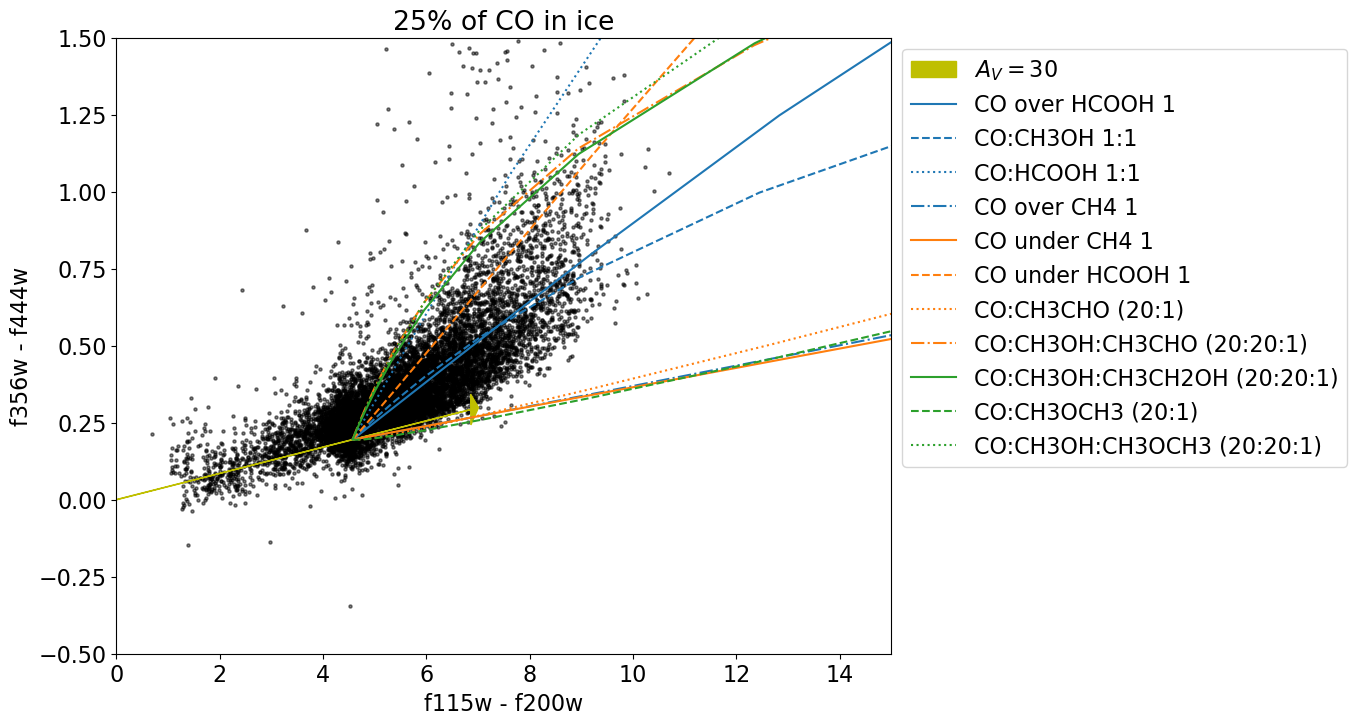

In [107]:
color1= ['F115W', 'F200W']
color2= ['F356W', 'F444W']
a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_with_icemodels(color1, color2, molids=[57, (64, 'lida'), 66, 67, 68, 69, 84, 86, 91, 94, 96],
                                                                                      #abundance=3e-4,
                                                                                      #nh2_to_av=1e22,
                                                                                      dmag_tbl=dmag_co,
                                                                                      abundance=0.25*carbon_abundance,
                                                                                      max_column=2e20)
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0))
pl.axis((0, 15, -0.5, 1.5));
pl.title("25% of CO in ice")

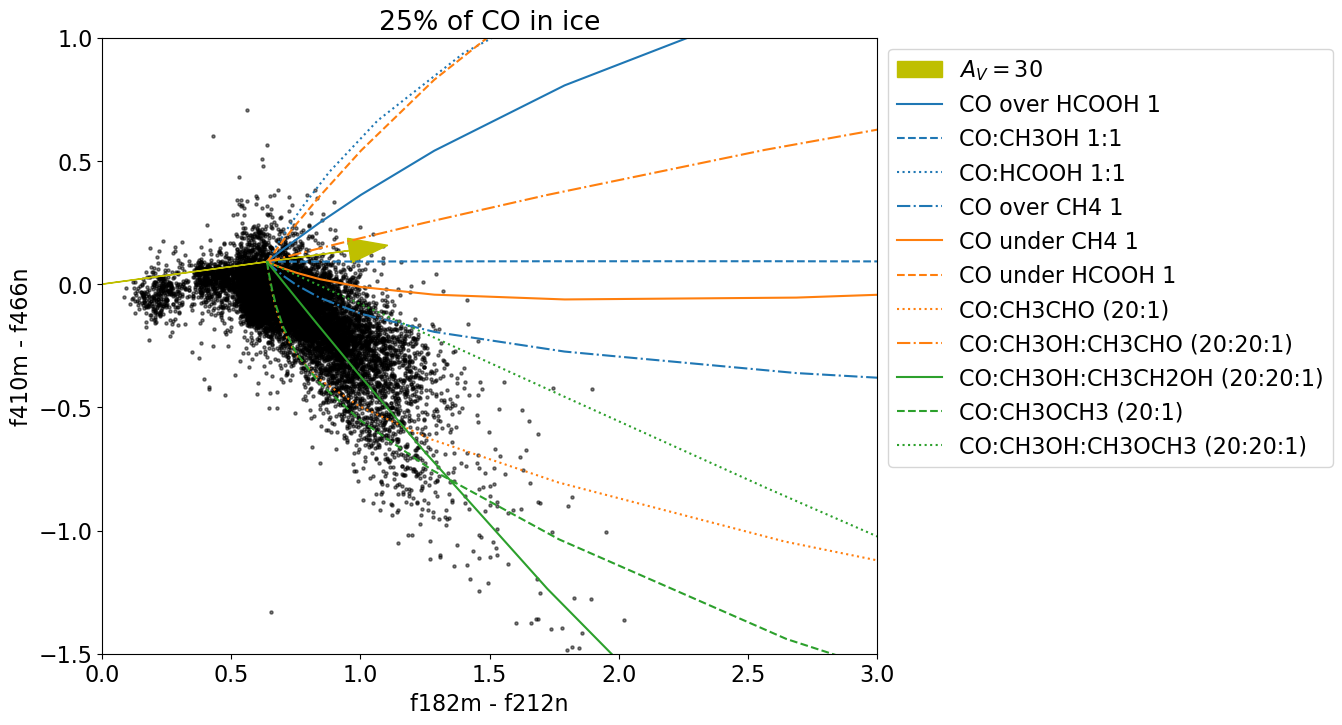

In [108]:
color1= ['F182M', 'F212N']
color2= ['F410M', 'F466N']
a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_with_icemodels(color1, color2, molids=[57, (64, 'lida'), 66, 67, 68, 69, 84, 86, 91, 94, 96],
                                                                                      #abundance=3e-4,
                                                                                      #nh2_to_av=1e22,
                                                                                      dmag_tbl=dmag_co,
                                                                                      abundance=0.25*carbon_abundance,
                                                                                      max_column=2e20)
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0))
pl.axis((0, 3, -1.5, 1.0));
pl.title("25% of CO in ice");

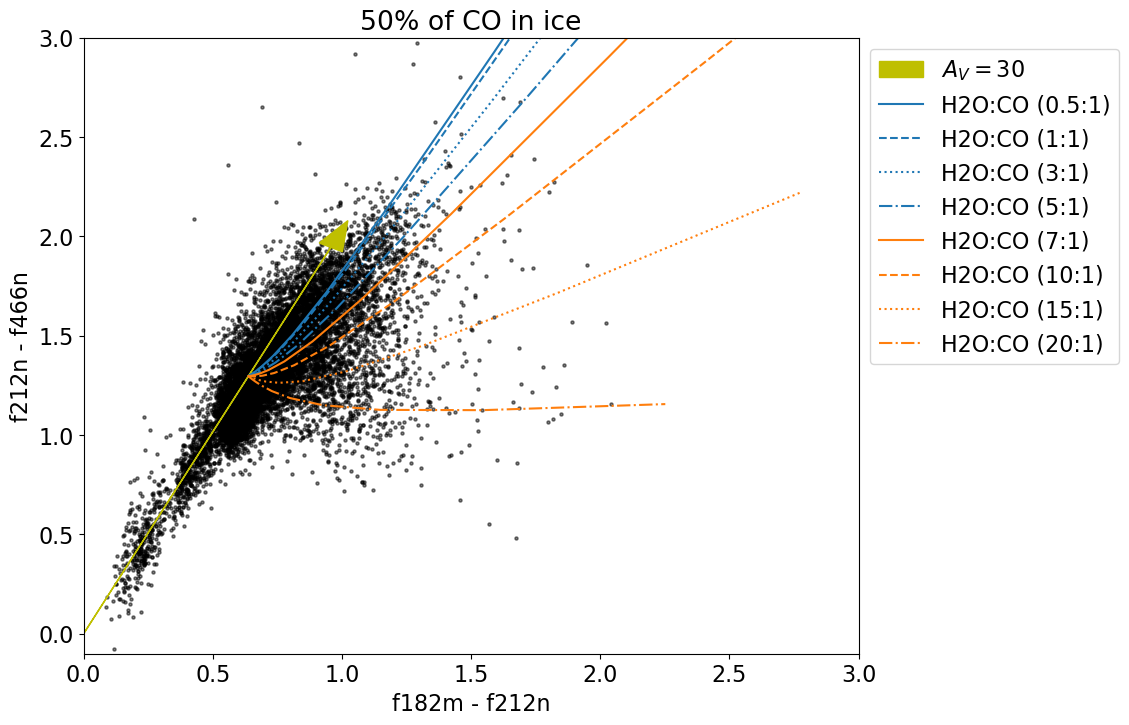

In [109]:
color1= ['F182M', 'F212N']
color2= ['F212N', 'F466N']
a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_with_icemodels(color1, color2, molids=[0,1,2,3,4,5,6,7],#4,5,6,7,8,9,10,11,12,13,14],
                                                                                  abundance=5e-5,
                                                                                  #nh2_to_av=1e22,
                                                                                  max_column=2e20)
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0))
pl.axis((0, 3, -0.1, 3.0));
pl.title("50% of CO in ice");

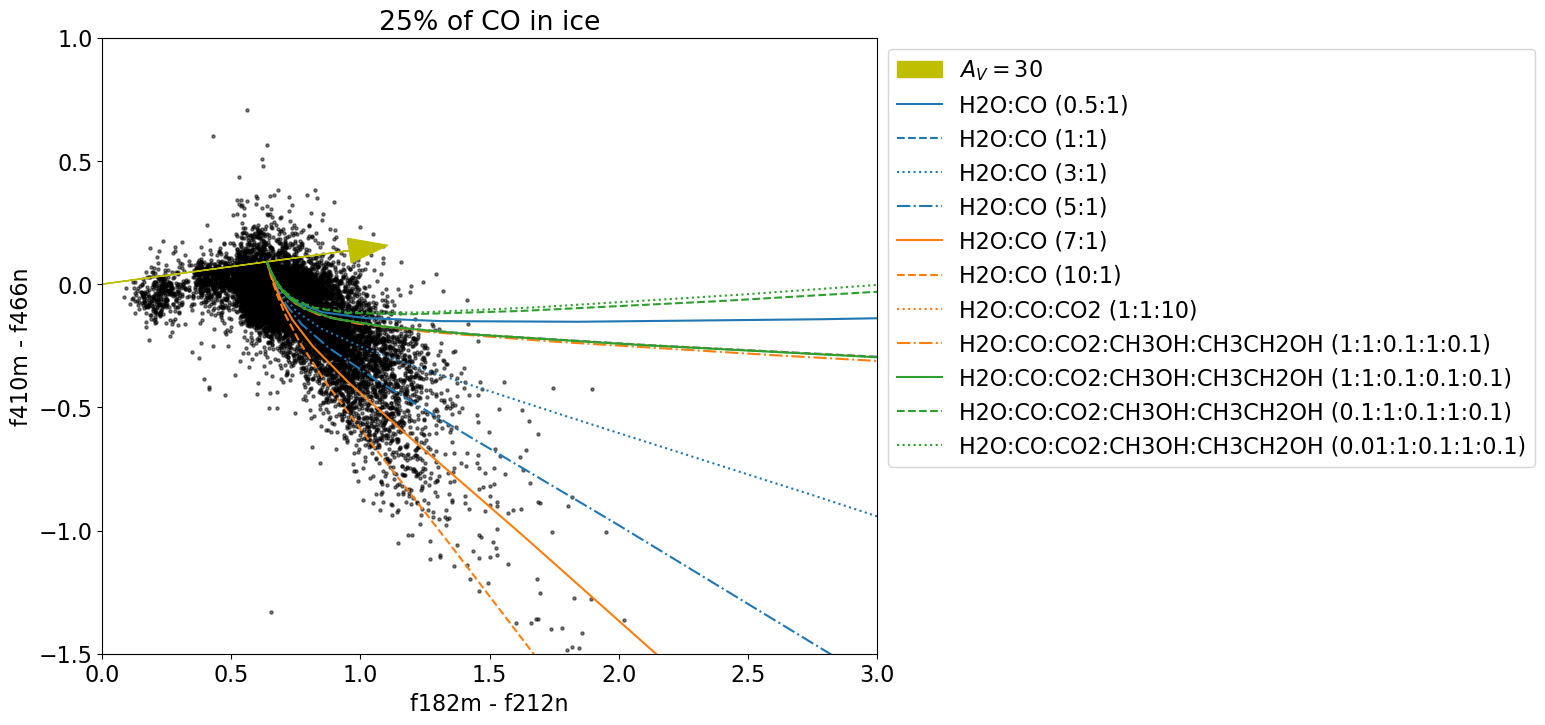

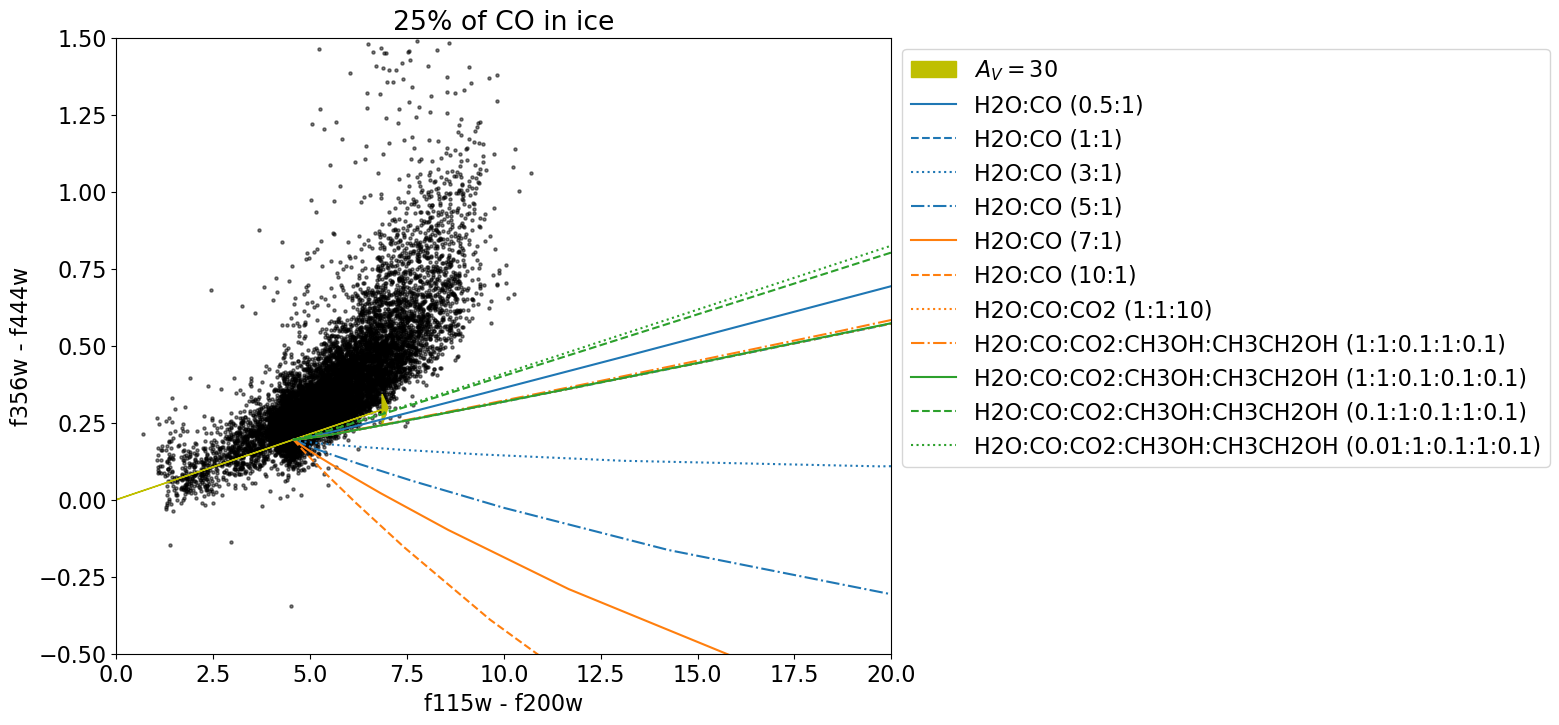

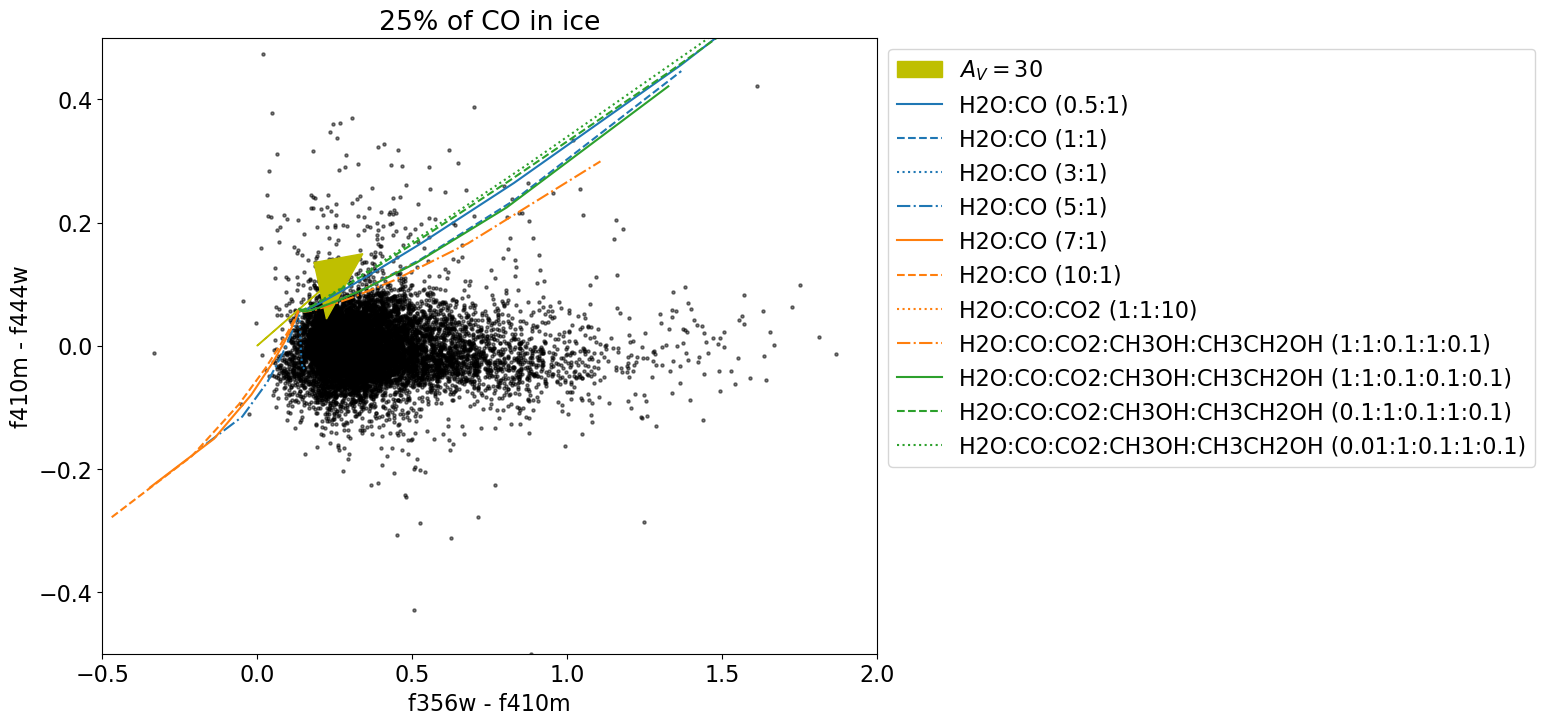

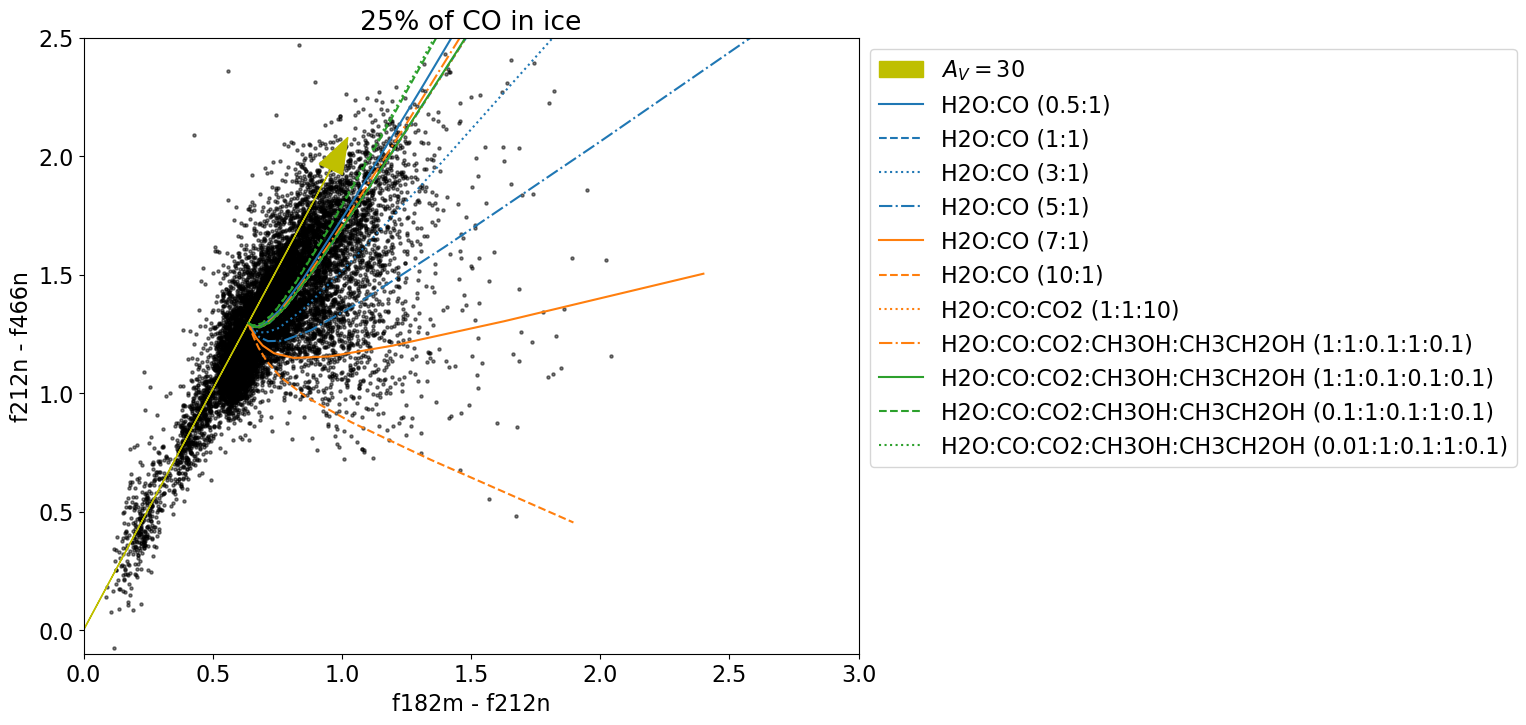

In [122]:
percent = 25

for color1, color2, lims in ((['F182M', 'F212N'], ['F410M', 'F466N'], (0, 3, -1.5, 1.0)),
                             (['F115W', 'F200W'], ['F356W', 'F444W'], (0, 20, -0.5, 1.5)),
                             (['F356W', 'F410M'], ['F410M', 'F444W'], (-0.5, 2, -0.5, 0.5)),
                             (['F182M', 'F212N'], ['F212N', 'F466N'], (0, 3, -0.1, 2.5)),
                             ):
    pl.figure();
    a_color1, a_color2, c1, c2, sel, E_V_color1, E_V_color2, tb = plot_ccd_with_icemodels(color1, color2, molids=[0,1,2,3,4,5,18,24,25,26,27],
                                                                                      #abundance=3e-4,
                                                                                      #nh2_to_av=1e22,
                                                                                      abundance=(percent/100.)*carbon_abundance,
                                                                                      max_column=2e20)
    pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0))
    pl.title(f"{percent}% of CO in ice");
    pl.axis(lims);

In [111]:
E_V_color1, E_V_color2

(0.0067860532967936385, 0.0029732995121951253)

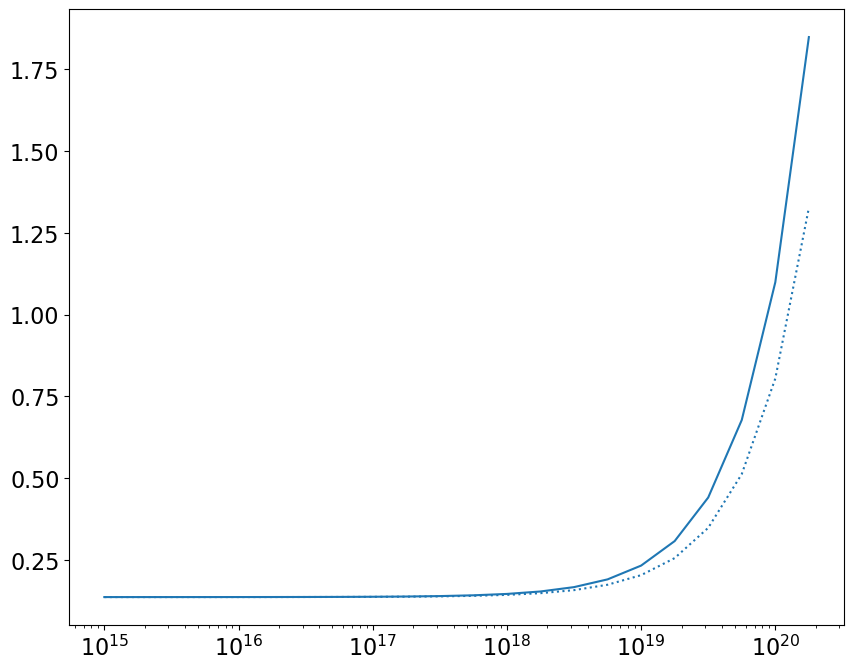

In [112]:
pl.semilogx(tb['column'][sel], a_color1)
pl.semilogx(tb['column'][sel], c1, linestyle=':')

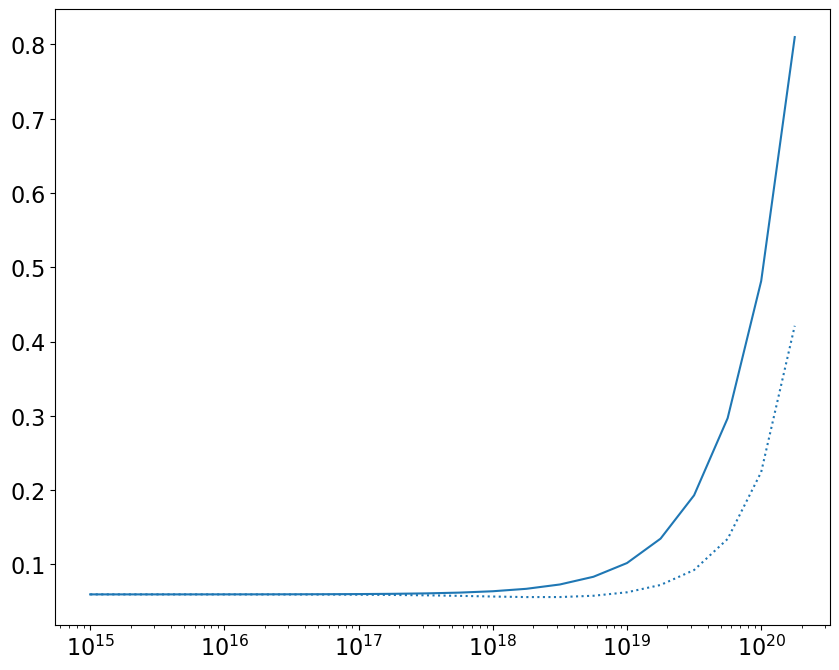

In [113]:
pl.semilogx(tb['column'][sel], a_color2)
pl.semilogx(tb['column'][sel], c2, linestyle=':')

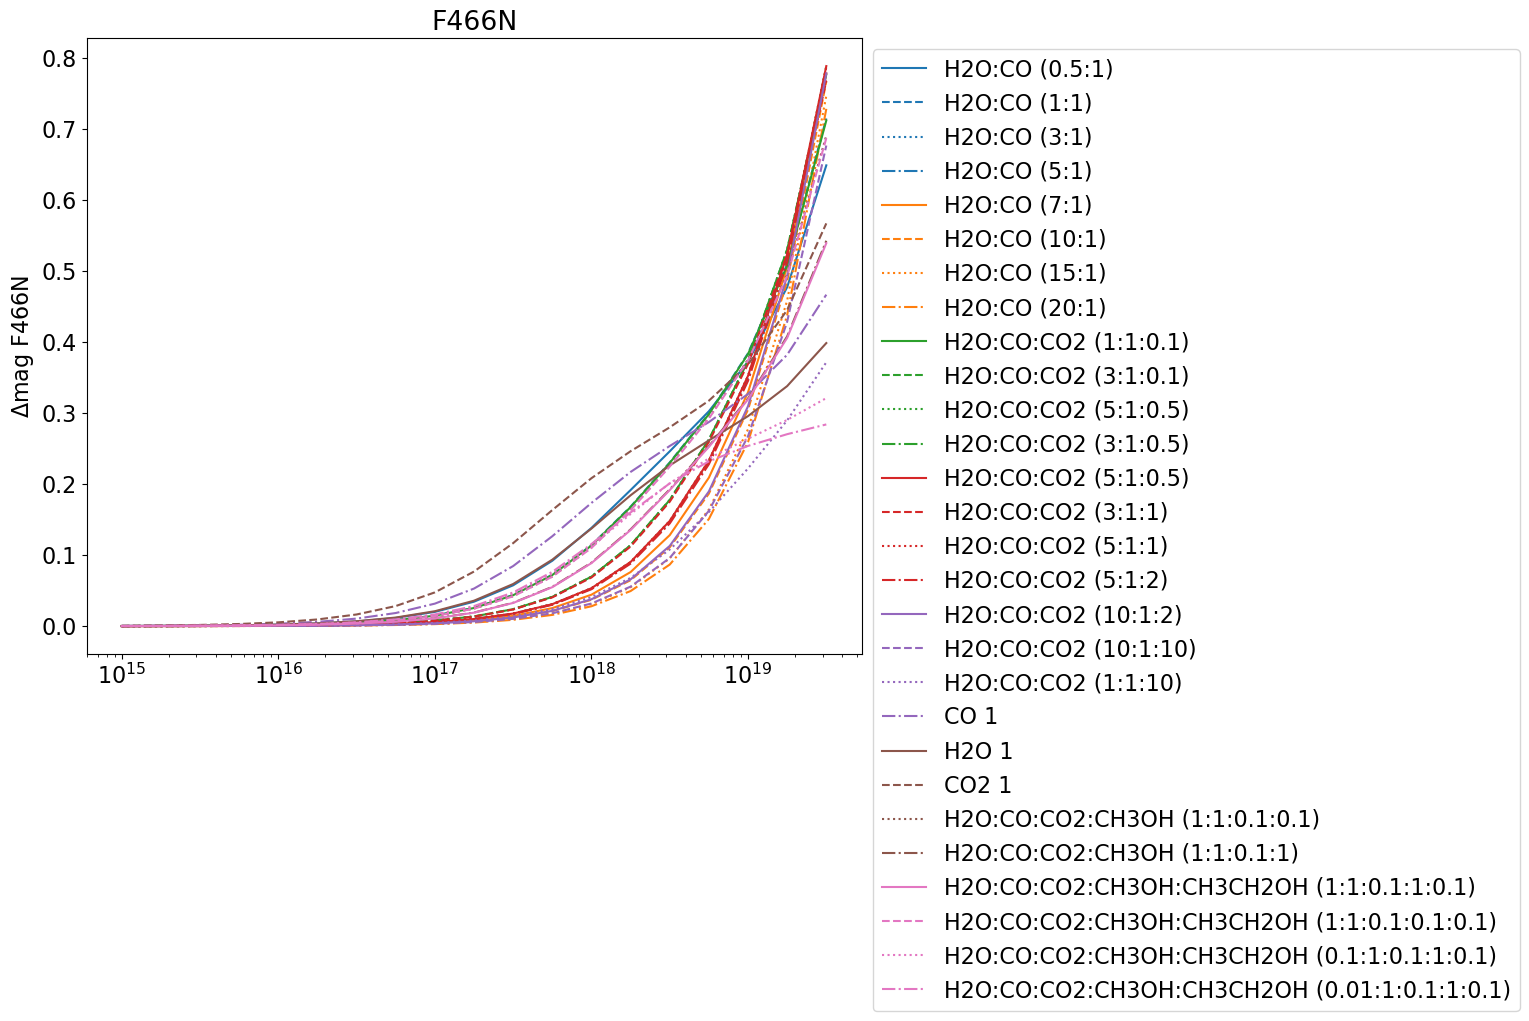

In [114]:
for molid in np.unique(dmag_mine['mol_id']):
    sel = dmag_mine.loc[molid]['column'] < 5e19
    comp = dmag_mine.loc[molid]['composition'][0]
    pl.semilogx(dmag_mine.loc[molid]['column'][sel], dmag_mine.loc[molid]['F466N'][sel], label=comp)
pl.title('F466N')
pl.ylabel('$\\Delta$mag F466N')
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0));

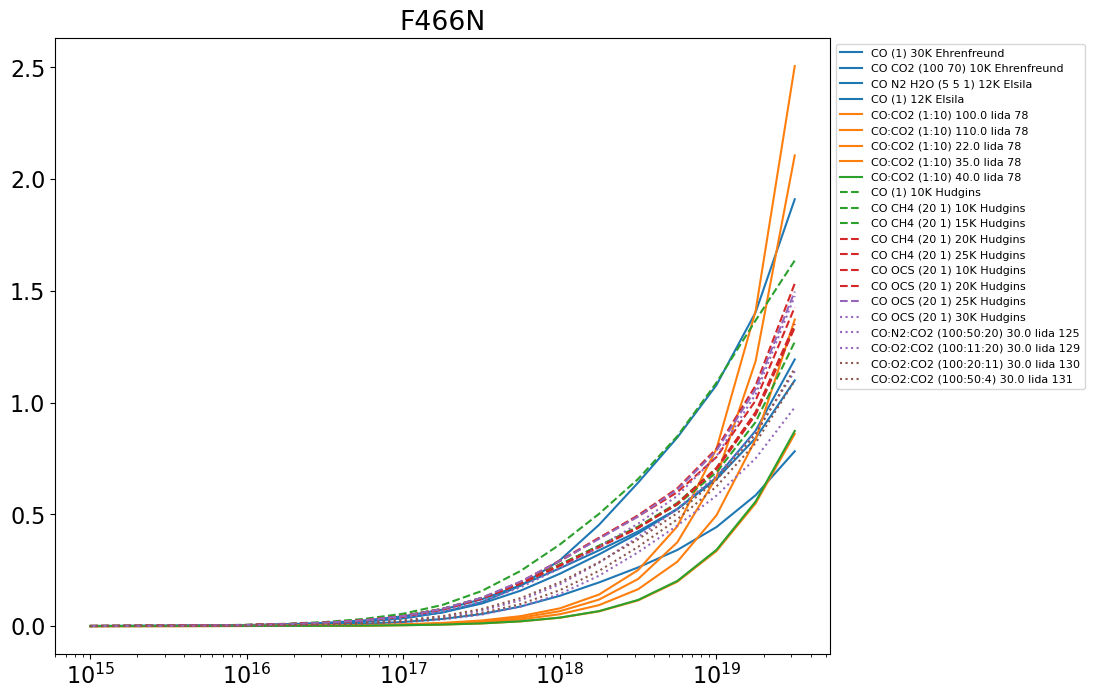

In [115]:
dmag_co.add_index('mol_id')
dmag_co.add_index('temperature')
ii = 0
for molid in np.unique(dmag_co['mol_id']):
    for temp in np.unique(dmag_co.loc[molid]['temperature']):
        tb = dmag_co.loc[molid].loc['temperature', temp]
        sel = tb['column'] < 5e19
        comp = tb['composition'][0]
        author = tb['author'][0] if 'author' in tb.colnames else ''
        if str(author) == '--':
            author = f"{tb['database'][0]} {molid}"
        if tb['F466N'][sel][-1] > 0.75 and 'under' not in comp and 'CH3' not in comp:
            linestyle = '-'
            if ii > 8:
                linestyle = '--'
            if ii > 16:
                linestyle = ':'
            pl.semilogx(tb['column'][sel], tb['F466N'][sel], label=f'{comp} {temp} {author}', linestyle=linestyle)
            ii += 1
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0), fontsize=8);
pl.title("F466N");

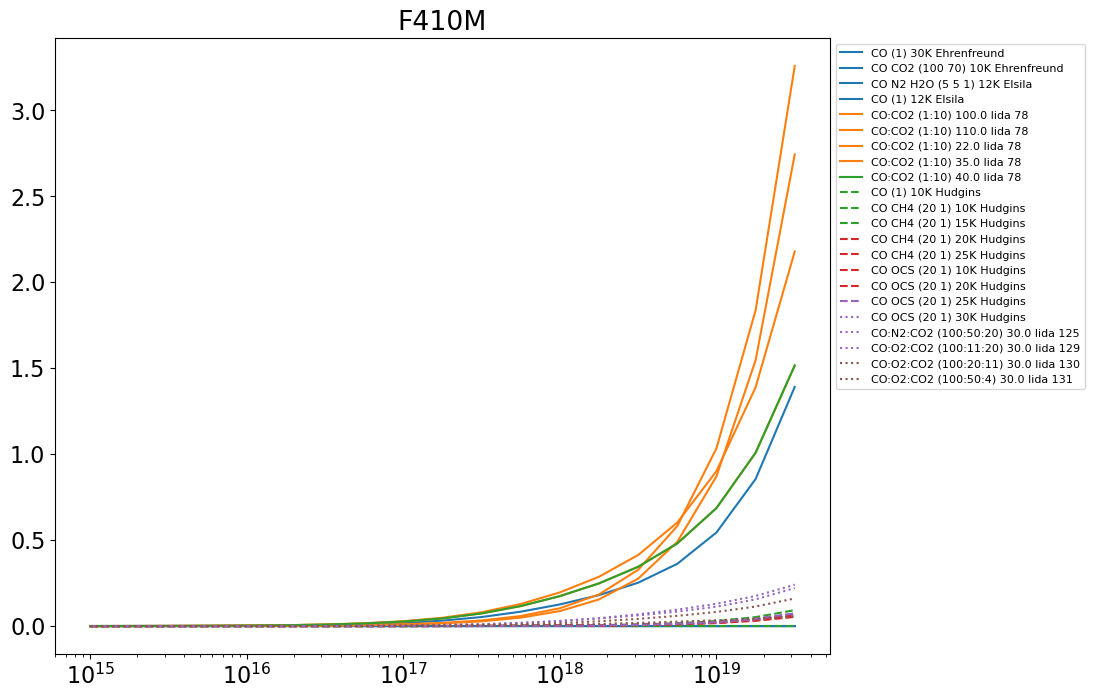

In [116]:
dmag_co.add_index('mol_id')
dmag_co.add_index('temperature')
ii = 0
for molid in np.unique(dmag_co['mol_id']):
    for temp in np.unique(dmag_co.loc[molid]['temperature']):
        tb = dmag_co.loc[molid].loc['temperature', temp]
        sel = tb['column'] < 5e19
        comp = tb['composition'][0]
        author = tb['author'][0] if 'author' in tb.colnames else ''
        if str(author) == '--':
            author = f"{tb['database'][0]} {molid}"
        if tb['F466N'][sel][-1] > 0.75 and 'under' not in comp and 'CH3' not in comp:
            linestyle = '-'
            if ii > 8:
                linestyle = '--'
            if ii > 16:
                linestyle = ':'
            pl.semilogx(tb['column'][sel], tb['F410M'][sel], label=f'{comp} {temp} {author}', linestyle=linestyle)
            ii += 1
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0), fontsize=8);
pl.title("F410M");

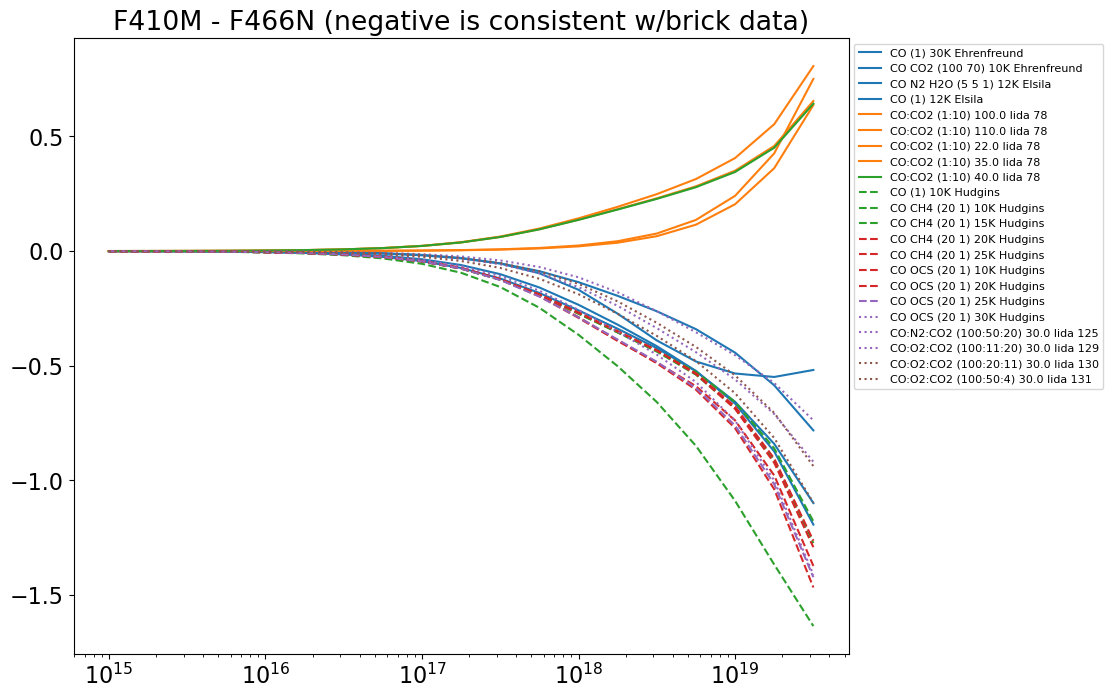

In [117]:
dmag_co.add_index('mol_id')
dmag_co.add_index('temperature')
ii = 0
for molid in np.unique(dmag_co['mol_id']):
    for temp in np.unique(dmag_co.loc[molid]['temperature']):
        tb = dmag_co.loc[molid].loc['temperature', temp]
        sel = tb['column'] < 5e19
        comp = tb['composition'][0]
        author = tb['author'][0] if 'author' in tb.colnames else ''
        molwt = tb['molwt'][0]
        if str(author) == '--':
            author = f"{tb['database'][0]} {molid}"
        if tb['F466N'][sel][-1] > 0.75 and 'under' not in comp and 'CH3' not in comp:
            linestyle = '-'
            if ii > 8:
                linestyle = '--'
            if ii > 16:
                linestyle = ':'
            pl.semilogx(tb['column'][sel], tb['F410M'][sel] - tb['F466N'][sel], label=f'{comp} {temp} {author}', linestyle=linestyle)
            ii += 1
pl.legend(loc='upper left', bbox_to_anchor=(1,1,0,0), fontsize=8);
pl.title("F410M - F466N (negative is consistent w/brick data)");

In [150]:
dmag_all = Table.read(f'{basepath}/tables/combined_ice_absorption_tables.ecsv')
dmag_all.add_index('mol_id')
dmag_all.add_index('composition')
dmag_all.add_index('temperature')
dmag_all.add_index('database')
dmag_all.add_index('column')

# Search for ice absorption to explain everything at N~10^19

* 410 - 466 < -0.5
* 212 - 466 < -0.5
* 356 - 444 > 0.25
* 356 - 410 > 0.25
* |410 - 444| < 0.1

In [9]:
N19[ice_candidate_selection]['composition']

<Column name='composition' dtype='str66' length=0>

loaded dmag_all
['F182M', 'F212N'] ['F410M', 'F466N']


  0%|          | 0/50 [00:00<?, ?it/s]

too many values to unpack (expected 2)
Not enough components in 'HCOOH 8 1'
Error converting composition HCOOH 8 1 to molwt: too many values to unpack (expected 2)
too many values to unpack (expected 2)
Not enough components in 'HCOOH 0.08 + H2O 0.62 + CO 0.3 1'
Error converting composition HCOOH 0.08 + H2O 0.62 + CO 0.3 1 to molwt: too many values to unpack (expected 2)
['F115W', 'F200W'] ['F356W', 'F444W']


  0%|          | 0/50 [00:00<?, ?it/s]

too many values to unpack (expected 2)
Not enough components in 'HCOOH 8 1'
Error converting composition HCOOH 8 1 to molwt: too many values to unpack (expected 2)
too many values to unpack (expected 2)
Not enough components in 'HCOOH 0.08 + H2O 0.62 + CO 0.3 1'
Error converting composition HCOOH 0.08 + H2O 0.62 + CO 0.3 1 to molwt: too many values to unpack (expected 2)
['F356W', 'F410M'] ['F410M', 'F444W']


  0%|          | 0/50 [00:00<?, ?it/s]

too many values to unpack (expected 2)
Not enough components in 'HCOOH 8 1'
Error converting composition HCOOH 8 1 to molwt: too many values to unpack (expected 2)
too many values to unpack (expected 2)
Not enough components in 'HCOOH 0.08 + H2O 0.62 + CO 0.3 1'
Error converting composition HCOOH 0.08 + H2O 0.62 + CO 0.3 1 to molwt: too many values to unpack (expected 2)
['F182M', 'F212N'] ['F212N', 'F466N']


  0%|          | 0/50 [00:00<?, ?it/s]

too many values to unpack (expected 2)
Not enough components in 'HCOOH 8 1'
Error converting composition HCOOH 8 1 to molwt: too many values to unpack (expected 2)
too many values to unpack (expected 2)
Not enough components in 'HCOOH 0.08 + H2O 0.62 + CO 0.3 1'
Error converting composition HCOOH 0.08 + H2O 0.62 + CO 0.3 1 to molwt: too many values to unpack (expected 2)


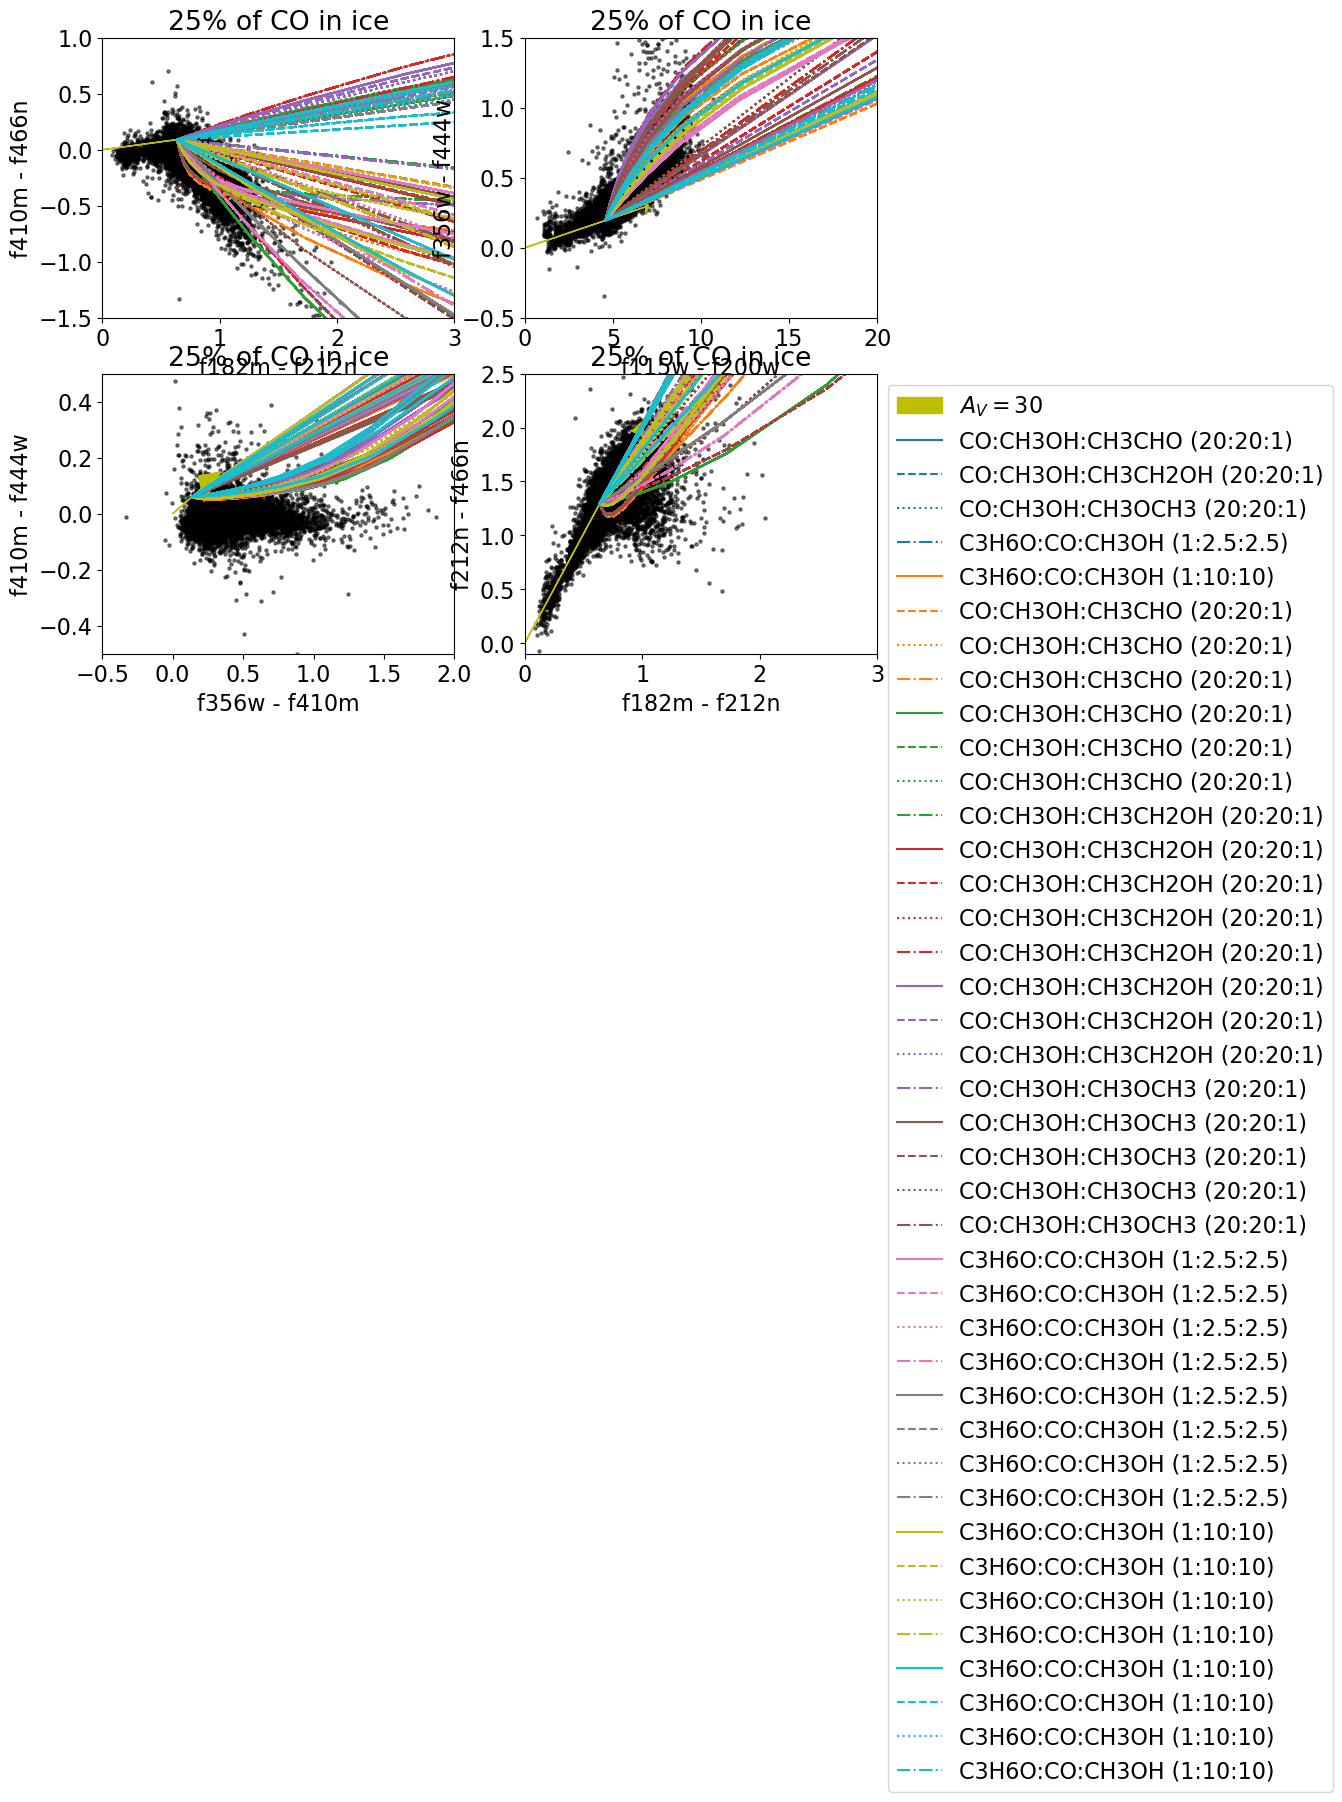

In [10]:
basepath = '/orange/adamginsburg/jwst/brick/'
%run $basepath/analysis/ice_candidate_search.py
#N19[ice_candidate_selection]

In [ ]:
len(dmag_all.loc['composition', N19[ice_candidate_selection]['composition']]) / 49